# 03 Experiments (CP1)

Сравнение baseline и одной экспериментальной модели на одинаковом split (`train/val/test`).

Приоритет метрики: **Macro-F1**.

In [23]:
from pathlib import Path
import sys
import json

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

In [24]:
ROOT = Path.cwd()
if not (ROOT / 'src' / 'modeling.py').exists():
    ROOT = ROOT.parent

sys.path.append(str(ROOT))

from src.modeling import run_cp1_experiments

In [25]:
output = run_cp1_experiments(
    processed_dir=ROOT / 'data' / 'processed',
    models_dir=ROOT / 'models',
    random_state=42,
)

results_df = output['results_df'].copy()
results_df

,model_id,model_name,feature_set,num_features,macro_f1_val,weighted_f1_val,accuracy_val,note
0,random_forest_exp,RandomForestClassifier,with_engineering,12,0.975758,0.979026,0.979133,Lightweight CP1 experiment with a tree model.
1,baseline_logreg,LogisticRegression,base,8,0.950756,0.956774,0.957133,CP1 baseline without using engineered features.


In [26]:
print('Best model:')
print(f"  id: {output['best_model_id']}")
print(f"  name: {output['best_model_name']}")
print(f"  feature set: {output['best_feature_set']}")

print('\nValidation metrics (best):')
for k, v in output['best_val_metrics'].items():
    print(f'  {k}: {v:.4f}')

print('\nTest metrics (best):')
for k, v in output['best_test_metrics'].items():
    print(f'  {k}: {v:.4f}')

Best model:
  id: random_forest_exp
  name: RandomForestClassifier
  feature set: with_engineering

Validation metrics (best):
  macro_f1: 0.9758
  weighted_f1: 0.9790
  accuracy: 0.9791

Test metrics (best):
  macro_f1: 0.9747
  weighted_f1: 0.9781
  accuracy: 0.9783


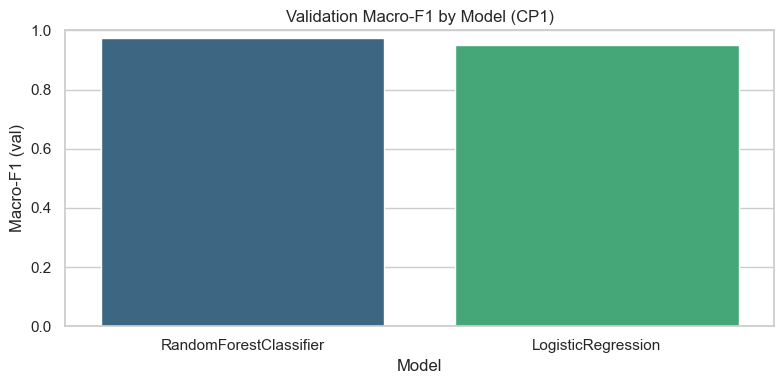

In [27]:
plot_df = results_df.sort_values('macro_f1_val', ascending=False).reset_index(drop=True)
plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x='model_name', y='macro_f1_val', palette='viridis', hue='model_name', legend=False)
plt.title('Validation Macro-F1 by Model (CP1)')
plt.xlabel('Model')
plt.ylabel('Macro-F1 (val)')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [28]:
results_path = Path(output['artifacts']['results_path'])
metrics_path = Path(output['artifacts']['metrics_path'])

saved_results = pd.read_csv(results_path)
saved_results

,model_id,model_name,feature_set,num_features,macro_f1_val,weighted_f1_val,accuracy_val,note
0,random_forest_exp,RandomForestClassifier,with_engineering,12,0.975758,0.979026,0.979133,Lightweight CP1 experiment with a tree model.
1,baseline_logreg,LogisticRegression,base,8,0.950756,0.956774,0.957133,CP1 baseline without using engineered features.


In [29]:
with open(output['artifacts']['metrics_path'], 'r', encoding='utf-8') as f:
    metrics_json = json.load(f)

metrics_json['best_model']

{'model_id': 'random_forest_exp',
 'model_name': 'RandomForestClassifier',
 'feature_set': 'with_engineering',
 'features': ['alpha',
  'delta',
  'u',
  'g',
  'r',
  'i',
  'z',
  'redshift',
  'u_g',
  'g_r',
  'r_i',
  'i_z']}

## Вывод

В CP1 экспериментальная модель `RandomForestClassifier` с инженерными признаками (`u_g`, `g_r`, `r_i`, `i_z`) улучшила качество относительно baseline:  
- `val`: Macro-F1 = 0.9758, Accuracy = 0.9791  
- `test`: Macro-F1 = 0.9747, Accuracy = 0.9783

Прирост по Macro-F1 относительно baseline составляет примерно +0.025 на `val` и +0.023 на `test`, что подтверждает полезность feature engineering уже на этапе CP1. Разница между `val` и `test` небольшая, значит модель обобщает стабильно и подходит как текущая лучшая модель.


## CP2: Experiments Part 1 + Part 2

В этом блоке запускаются дополнительные эксперименты CP2:
- **Part 1:** новые модели + ансамбли.
- **Part 2:** перебор гиперпараметров.


In [38]:
from pathlib import Path
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "src" / "cp2_experiments.py").exists():
    ROOT = ROOT.parent

MODELS_DIR = ROOT / "models"
cp2_results_path = MODELS_DIR / "cp2_results.csv"
cp2_metrics_path = MODELS_DIR / "cp2_metrics.json"


In [35]:
cp2_results = pd.read_csv(cp2_results_path)
cp2_results = cp2_results.sort_values("macro_f1_val", ascending=False).reset_index(drop=True)
cp2_results[[
    "phase", "model_id", "model_name",
    "macro_f1_val", "accuracy_val",
    "macro_f1_test", "accuracy_test",
    "best_params"
]]


,phase,model_id,model_name,macro_f1_val,accuracy_val,macro_f1_test,accuracy_test,best_params
0,part1,hist_gb_exp,HistGradientBoostingClassifier,0.974564,0.978000,0.973902,0.977468,NaN
1,part2_tuning,extra_trees_tuned,ExtraTreesClassifier,0.974269,0.977667,0.972470,0.976068,"{""max_depth"": 24, ""max_features"": null, ""min_s..."
2,part2_tuning,hist_gb_tuned,HistGradientBoostingClassifier,0.973801,0.977333,0.973756,0.977335,"{""l2_regularization"": 0.5, ""learning_rate"": 0...."
3,part1,stacking_exp,StackingClassifier,0.973471,0.976800,0.974054,0.977468,NaN
4,part1,extra_trees_exp,ExtraTreesClassifier,0.968954,0.972800,0.967923,0.971802,NaN
5,part1,voting_soft_exp,VotingClassifier,0.967689,0.971867,0.967130,0.971402,NaN
6,part1,knn_exp,KNeighborsClassifier,0.926759,0.934267,0.921744,0.929871,NaN
7,part1,gaussian_nb_exp,GaussianNB,0.921788,0.928933,0.922233,0.929138,NaN
8,part1,adaboost_exp,AdaBoostClassifier,0.851883,0.873200,0.850129,0.871275,NaN


In [36]:
with open(cp2_metrics_path, "r", encoding="utf-8") as f:
    cp2_metrics = json.load(f)

print("Best model:", cp2_metrics["best_model"])
print("\nValidation metrics:", cp2_metrics["validation_metrics_best_model"])
print("\nTest metrics:", cp2_metrics["test_metrics_best_model"])
print("\nTuning summaries:")
for row in cp2_metrics.get("tuning_summaries", []):
    print(row)


Best model: {'model_id': 'hist_gb_exp', 'model_name': 'HistGradientBoostingClassifier', 'phase': 'part1', 'feature_set': 'with_engineering', 'features': ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'u_g', 'g_r', 'r_i', 'i_z']}

Validation metrics: {'macro_f1': 0.9745642592256831, 'weighted_f1': 0.9779262954785997, 'accuracy': 0.978}

Test metrics: {'macro_f1': 0.973901691446045, 'weighted_f1': 0.9773481139555166, 'accuracy': 0.9774681687887474}

Tuning summaries:
{'model_id': 'extra_trees_tuned', 'model_name': 'ExtraTreesClassifier', 'tune_samples': 25000, 'cv_splits': 3, 'n_iter': 8, 'best_cv_macro_f1': 0.9710992683872055, 'best_params': {'n_estimators': 260, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 24}}
{'model_id': 'hist_gb_tuned', 'model_name': 'HistGradientBoostingClassifier', 'tune_samples': 25000, 'cv_splits': 3, 'n_iter': 8, 'best_cv_macro_f1': 0.971519439007197, 'best_params': {'min_samples_leaf': 20, 'max_leaf_nodes': 31, 'max_depth': 14, 'learning

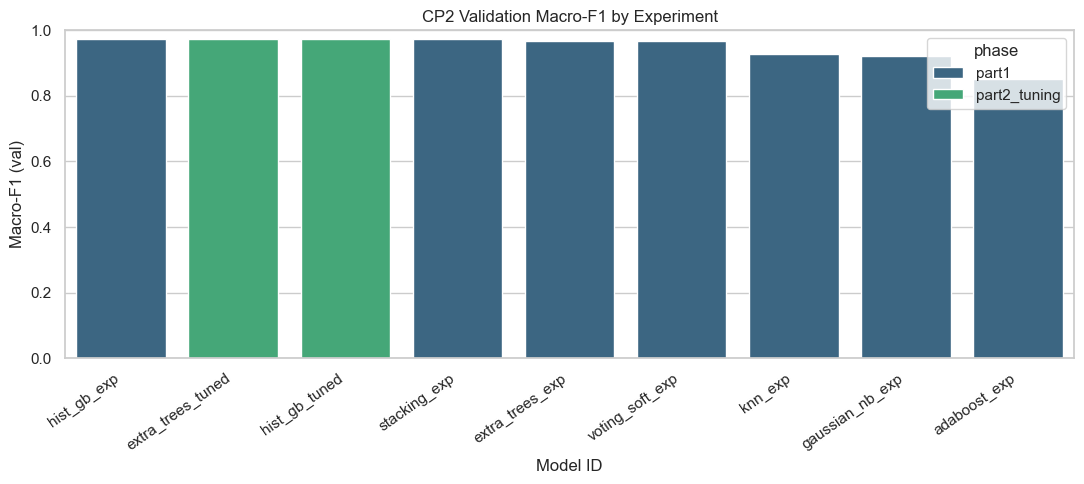

In [37]:
plot_df = cp2_results.copy()
plt.figure(figsize=(11, 5))
sns.barplot(
    data=plot_df,
    x="model_id",
    y="macro_f1_val",
    hue="phase",
    dodge=False,
    palette="viridis",
)
plt.title("CP2 Validation Macro-F1 by Experiment")
plt.xlabel("Model ID")
plt.ylabel("Macro-F1 (val)")
plt.xticks(rotation=35, ha="right")
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()


## CP2 Вывод

В CP2 мы проверили гипотезу о том, что более сильные ансамблевые и бустинговые подходы на расширенном наборе признаков (`u_g`, `g_r`, `r_i`, `i_z`) смогут улучшить итоговое качество по всем классам, включая `QSO`.

Проверка была сделана в двух частях: сначала обучили новые модели и ансамбли (`part1`), затем отдельно провели тюнинг гиперпараметров для `ExtraTrees` и `HistGradientBoosting` через `RandomizedSearchCV` (`part2`).

Лучший результат показала модель `HistGradientBoostingClassifier (hist_gb_exp)` из `part1`: `Macro-F1 val = 0.9746`, `Macro-F1 test = 0.9739`. Тюнинг в `part2` дал близкие результаты (`0.9743` и `0.9738` на валидации), но не превзошел лучший фиксированный запуск.

Итоговый выбор внутри CP2 — `hist_gb_exp`: у нее максимальный `Macro-F1` на валидации и минимальный разрыв между `val` и `test`, что говорит о стабильном обобщении модели.
